In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy import stats
from shared.utils import u_style, u_stats
from shared.LMCS import glob_util
from shared.paths import load_paths
import ipdb

u_style.set_mpl_style()

%matplotlib inline

In [38]:
REGIONS = glob_util.REGIONS
style = glob_util.REGION_STYLE


paths = load_paths()
ROOT = paths.datasets["obs_mcs_5000km2_tables_ERA"]
print("Using ROOT:", ROOT)
YEARS = range(2000, 2020)

REGION='GPlains'

Using ROOT: /prj/global_water/MCS_5000km2_tables_v3/ERA5_storm_timeseries


In [75]:
REGIONS

{'GPlains': [[-110, -90, 31, 48], 'nam', -6, (5, 9), (1, 12)],
 'Eur': [[-10, 28, 38, 53], 'nam', 1, (5, 9), (1, 12)],
 'china': [[105, 120, 20, 45], 'asia', 8, (5, 9), (1, 12)],
 'india': [[70, 90, 5, 30], 'asia', 5, (5, 9), (1, 12)],
 'WAf': [[-18, 25, 4, 25], 'spac', 0, (5, 9), (1, 12)],
 'australia': [[120, 140, -25, -11], 'asia', 9, (11, 3), (1, 12)],
 'SAf': [[17, 33, -32, -14], 'spac', 2, (11, 3), (1, 12)],
 'sub_SA': [[-68, -45, -40, -20], 'spac', -4, (11, 3), (1, 12)],
 'trop_SA': [[-75, -45, -20, 0], 'spac', -4, (11, 3), (1, 12)],
 'CAf': [[13.5, 29, -14, 4], 'spac', 1, (11, 3), (1, 12)],
 'EAf': [[29, 44, -2.5, 15.5], 'spac', 2, (3, 7), (1, 12)],
 'Atl': [[-46, -18, 4, 25], 'spac', -2, (6, 10), (1, 12)],
 'Pcf': [[-135, -110, -15, 20], 'spac', -8, (7, 11), (1, 12)],
 'InO': [[55, 82, -15, 5], 'spac', 5, (11, 3), (1, 12)]}

In [76]:
style

{'WAf': {'color': 'firebrick', 'ls': '-', 'label': 'West Africa'},
 'CAf': {'color': 'darkorange', 'ls': '-', 'label': 'Central Africa'},
 'EAf': {'color': 'goldenrod', 'ls': '-', 'label': 'East Africa'},
 'india': {'color': 'saddlebrown', 'ls': '-', 'label': 'India'},
 'trop_SA': {'color': 'olivedrab',
  'ls': '-',
  'label': 'Tropical South America'},
 'australia': {'color': 'peru', 'ls': '-', 'label': 'Australia'},
 'GPlains': {'color': 'royalblue', 'ls': '-', 'label': 'Great Plains'},
 'Eur': {'color': 'teal', 'ls': '-', 'label': 'Europe'},
 'china': {'color': 'navy', 'ls': '-', 'label': 'China'},
 'sub_SA': {'color': 'purple',
  'ls': '-',
  'label': 'Subtropical South America'},
 'SAf': {'color': 'black', 'ls': '-', 'label': 'South Africa'},
 'Atl': {'color': 'deepskyblue', 'ls': '--', 'label': 'Atlantic'},
 'Pcf': {'color': 'turquoise', 'ls': '--', 'label': 'Pacific'},
 'InO': {'color': 'mediumseagreen', 'ls': '--', 'label': 'Indian Ocean'}}

In [40]:
ERA_VARS = [
    "tcwv",
    "shear100_650",
    "ushear100_650",
    "q925",
    "q650",
    "cape",
]

TARGETS= ["precipitation_maximum",
    "rainfall_area",
    "area",
]

In [42]:
def read_meta(region):
    files = [
        f"{ROOT}/storm_metadata/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [pd.read_parquet(f) for f in files],
        ignore_index=True
    )


def read_var(var, region):
    files = [
        f"{ROOT}/{var}/region={region}/year={y}/part.parquet"
        for y in YEARS
    ]

    files = [f for f in files if os.path.isfile(f)]

    return pd.concat(
        [
            pd.read_parquet(
                f,
                columns=["storm_id", "rel_hour", "value"]
            )
            for f in files
        ],
        ignore_index=True
    )


def region_df(region, rel_hour=0):
    df = read_meta(region).copy()

    for var in ERA_VARS:
        tmp = read_var(var, region)

        tmp = (
            tmp[tmp["rel_hour"] == rel_hour]
            [["storm_id", "value"]]
            .drop_duplicates("storm_id")
            .rename(columns={"value": var})
        )

        df = df.merge(tmp, on="storm_id", how="left")

    df["region"] = region

    return df

def build_all_regions(variables):

    dfs = []

    for region in REGIONS:

        meta = read_meta(region)

        if meta is None:
            continue

        df = None

        for var in variables:

            tmp = read_var(var, region)

            tmp = tmp.rename(columns={"value": var})

            if df is None:
                df = tmp
            else:
                df = df.merge(
                    tmp[["storm_id", "rel_hour", var]],
                    on=["storm_id", "rel_hour"],
                    how="outer",
                )

        df = df.merge(meta, on="storm_id", how="left")

        df["region"] = region

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [43]:
df_all = build_all_regions(["tcwv", "shear100_650", "q925", "cape"])

In [ ]:
# #df_all = region_df(REGION, rel_hour=-4)

# df = df_all[
#     (df_all["storm_lt_hour"].between(13, 18)) &
#     ((df_all["lsm"] > 0.8) | (df_all["lsm"] < 0.2)) &
#     (df_all["topographic_complexity"] < 150)
# ].copy()

# print(len(df_all), "storms before filtering")
# print(len(df), "storms after filtering")

88712 storms before filtering
73008 storms after filtering


In [116]:
df_storm = df_all[(df_all["rel_hour"] == 0) & (df_all["storm_lt_hour"].between(13, 18))].copy()
df_env = df_all[(df_all["rel_hour"] == -3) & (df_all["storm_lt_hour"].between(13, 18))].copy()
print(len(df_all), "storms before filtering")
print(len(df_env), "storms after filtering")

29326120 storms before filtering
1903162 storms after filtering


In [117]:
np.unique(df_env['storm_lt_hour'])

array([13, 14, 15, 16, 17, 18], dtype=int32)

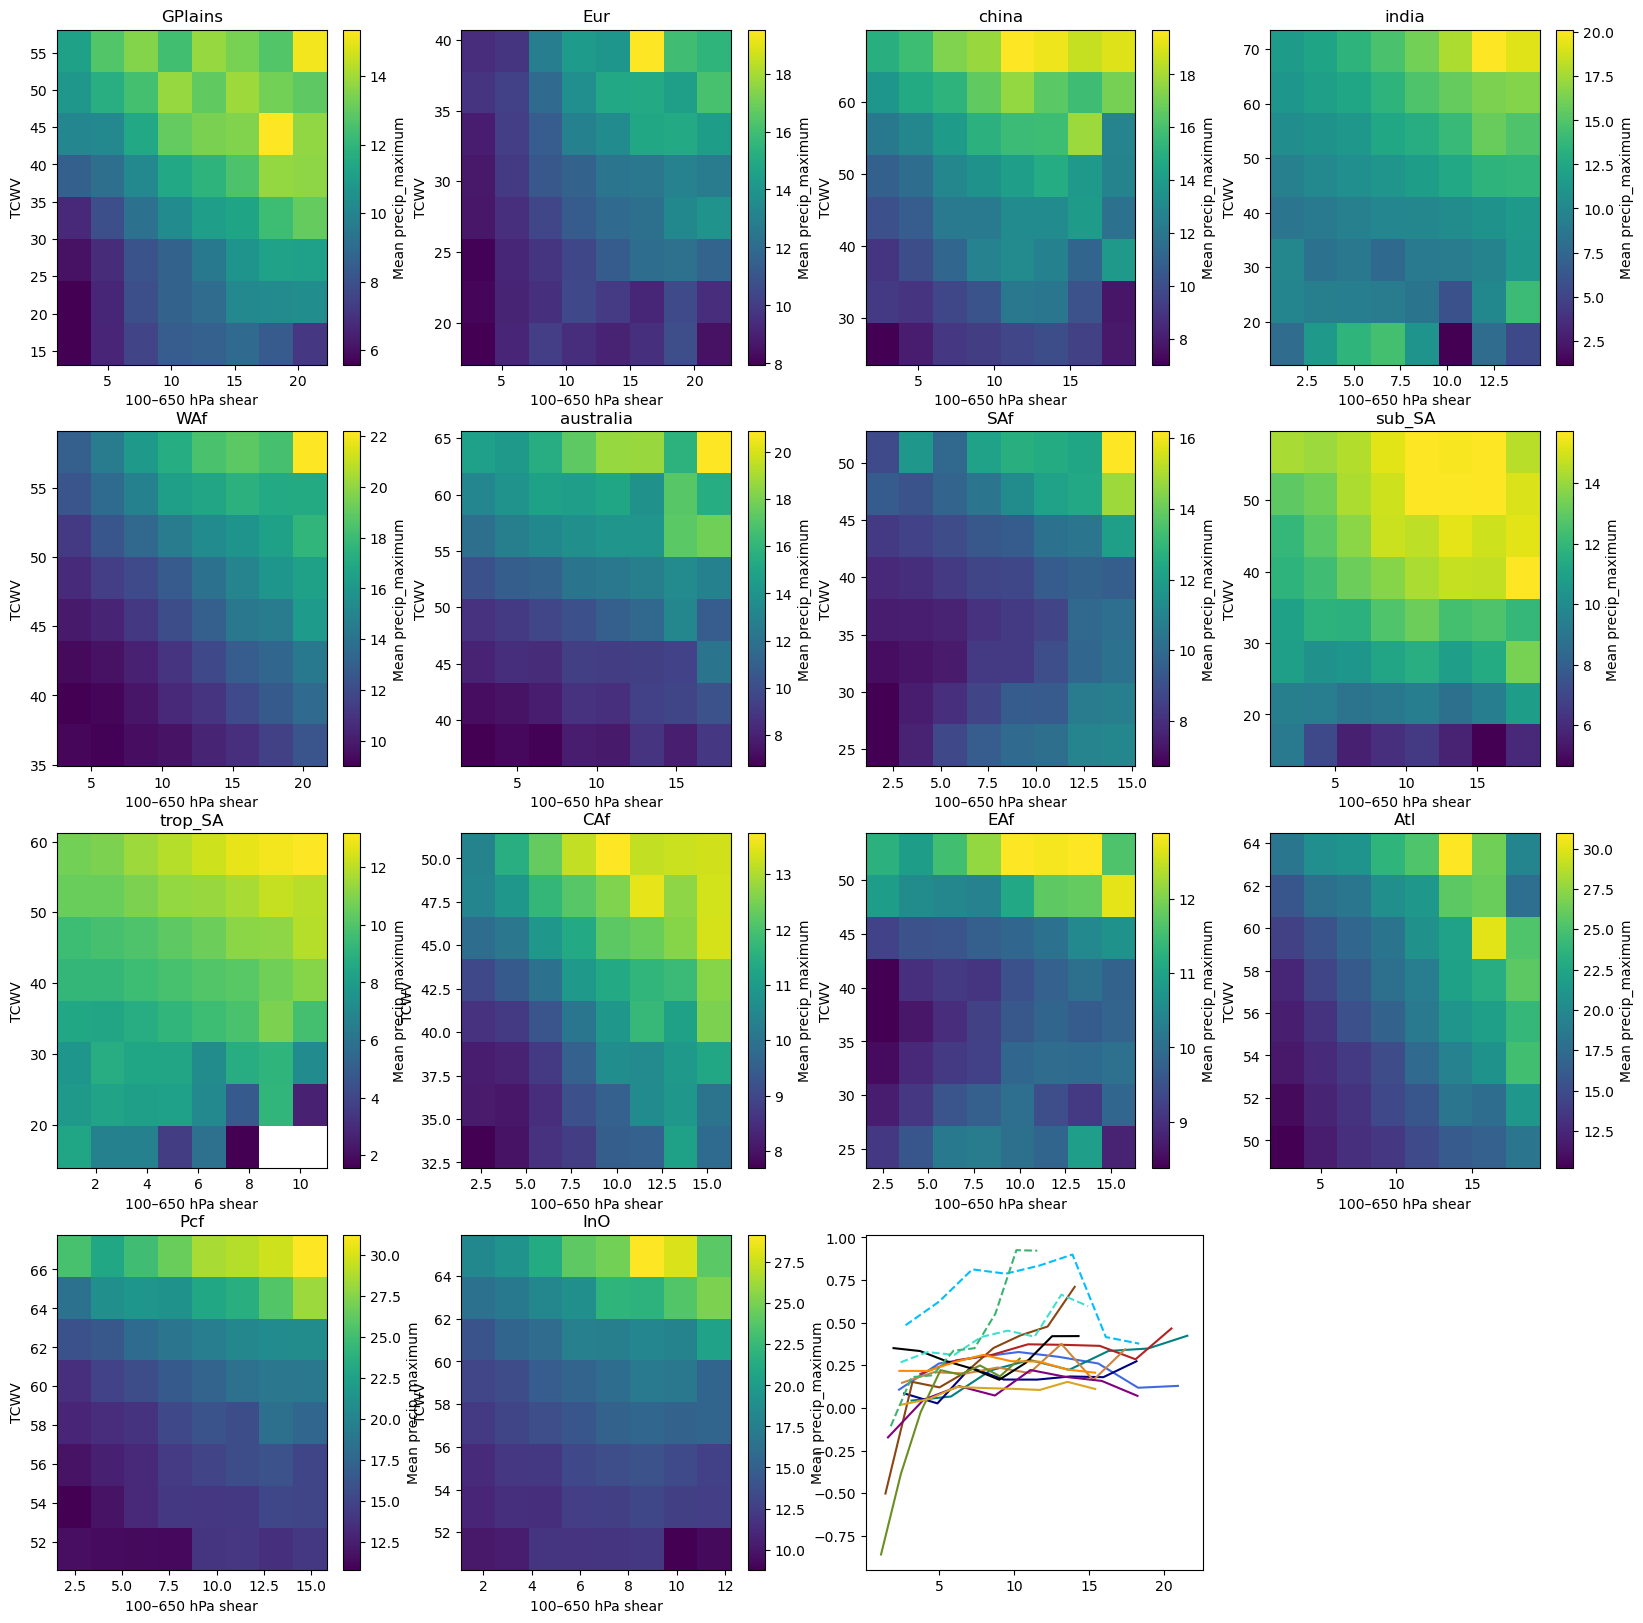

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [119]:
f = plt.figure(figsize=(20, 20))
ax_line = f.add_subplot(4,4,15)
for ids, reg in enumerate(REGIONS):
    rdf = df_env[df_env['region'] == reg]

    x = rdf["shear100_650"]
    y = rdf["tcwv"]
    z = rdf["precipitation_max"]

    # print(type(x), getattr(x, "dtype", None))
    # print(type(y), getattr(y, "dtype", None))
    # print(type(z), getattr(z, "dtype", None))

    # print(np.shape(x), np.shape(y), np.shape(z))

    # print("x percentiles:", np.nanpercentile(x, [1, 99]))
    # print("y percentiles:", np.nanpercentile(y, [1, 99]))

    func = np.nanmean
    
    stat, xedge, yedge, _ = stats.binned_statistic_2d(x,y,z,
        statistic=func,
        bins=[8,8],
        range = [[np.nanpercentile(x,5), np.nanpercentile(x,99)],[np.nanpercentile(y,5), np.nanpercentile(y,99)]])

    ax = f.add_subplot(4,4,ids+1)
    mp = ax.pcolormesh(xedge, yedge, stat.T, shading="auto")
    plt.colorbar(mp, label="Mean precip_maximum")
    plt.xlabel("100–650 hPa shear")
    plt.ylabel("TCWV")
    plt.title(reg)

    shear_centres = 0.5 * (xedge[:-1] + xedge[1:])
    slope, ci, p = u_stats.ols_slope_2d(shear_centres, stat.T, min_bin_n=5, axis=1)

    ax_line.plot(shear_centres, slope, color=style[reg]["color"], label=reg, ls=style[reg]["ls"])
    
    
plt.show()
plt.tight_layout

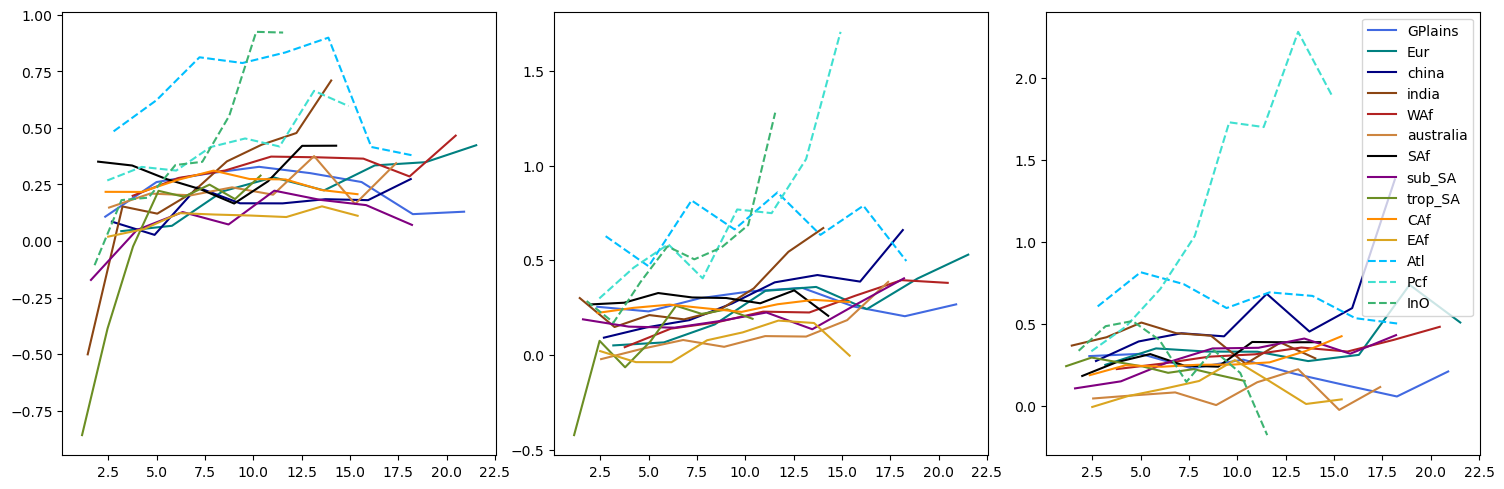

In [120]:
f = plt.figure(figsize=(15, 5))

for id, var in enumerate(["tcwv", "q925", "cape"]):
    ax = f.add_subplot(1,3,id+1)
    for ids, reg in enumerate(REGIONS):
        rdf = df_env[df_env['region'] == reg]

        multi=1
        if var == "q925":
            multi = 1000

        x = rdf["shear100_650"]
        y = rdf[var]*multi
        z = rdf["precipitation_max"]

        func = np.nanmean
        
        stat, xedge, yedge, _ = stats.binned_statistic_2d(x,y,z,
            statistic=func,
            bins=[8,8],
            range = [[np.nanpercentile(x,5), np.nanpercentile(x,99)],[np.nanpercentile(y,5), np.nanpercentile(y,99)]])

        shear_centres = 0.5 * (xedge[:-1] + xedge[1:])
        slope, ci, p = u_stats.ols_slope_2d(shear_centres, stat.T, min_bin_n=5, axis=1)
        ax.plot(shear_centres, slope, color=style[reg]["color"], label=reg, ls=style[reg]["ls"])
plt.legend()  
plt.tight_layout()
plt.show()


In [121]:
# ── CONFIG — only edit here ───────────────────────────────────────────────────
 
TCW_BINS = [
    ('Low\n(0–10th)',    1,  20),
    ('Mid\n(45–55th)',  40,  60),
    ('High\n(90–100th)',80, 99),
]
 
COLORS = {
    'Low\n(0–10th)':    '#4393c3',
    'Mid\n(45–55th)':   '#f4a582',
    'High\n(90–100th)': '#d6604d',
}
# ─────────────────────────────────────────────────────────────────────────────
 
 
def shear_slope(df, response_col, tcw_lo, tcw_hi):
    """
    OLS slope of response_col ~ SHEAR_COL within a TCW percentile band.
    Returns (slope, 95%-CI half-width), or (nan, nan) if too few points.
    """

    lo = np.nanpercentile(df[TCW_COL], tcw_lo)
    hi = np.nanpercentile(df[TCW_COL], tcw_hi)
    sub = df[(df[TCW_COL] >= lo) & (df[TCW_COL] <= hi)].dropna(
        subset=[SHEAR_COL, response_col])
 
    if len(sub) < 5:
        return np.nan, np.nan
 
    slope, _, _, _, se = stats.linregress(sub[SHEAR_COL], sub[response_col])
    ci = stats.t.ppf(0.975, df=len(sub) - 2) * se
    return slope, ci
 
 
def plot_shear_scaling(data, response_col, ylabel, title):
    regions   = REGIONS
    n_regions = len(regions)
 
    bar_width = 0.22
    x = np.arange(n_regions) * (len(TCW_BINS) * bar_width + 0.25)
 
    fig, ax = plt.subplots(figsize=(max(10, n_regions * 1.8), 5.5))
 
    for i, (label, lo, hi) in enumerate(TCW_BINS):
        slopes, cis = [], []
        for region in regions:
           
            dat = data[data['region'] == region]
            s, c = shear_slope(dat, response_col, lo, hi)
           
            slopes.append(s)
            cis.append(c)
 
        offsets = x + (i - 1) * bar_width
        ax.bar(offsets, slopes, width=bar_width,
               label=label, color=COLORS[label],
               edgecolor='white', linewidth=0.6, zorder=3)
 
        for j, (s, c) in enumerate(zip(slopes, cis)):
            if not np.isnan(s) and not np.isnan(c):
                ax.errorbar(offsets[j], s, yerr=c, fmt='none',
                            ecolor='#333333', elinewidth=1.2,
                            capsize=3, capthick=1.2, zorder=4)
 
    ax.axhline(0, color='#555555', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(regions, fontsize=9.5, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(title=f'{TCW_COL} bin', fontsize=8.5, title_fontsize=9,
              framealpha=0.9, edgecolor='#cccccc', loc='upper right')
 
    fig.tight_layout()
    # fig.savefig(outpath, dpi=180, bbox_inches='tight')
    # print(f"Saved -> {outpath}")
    # plt.close(fig)
    fig.show()
 

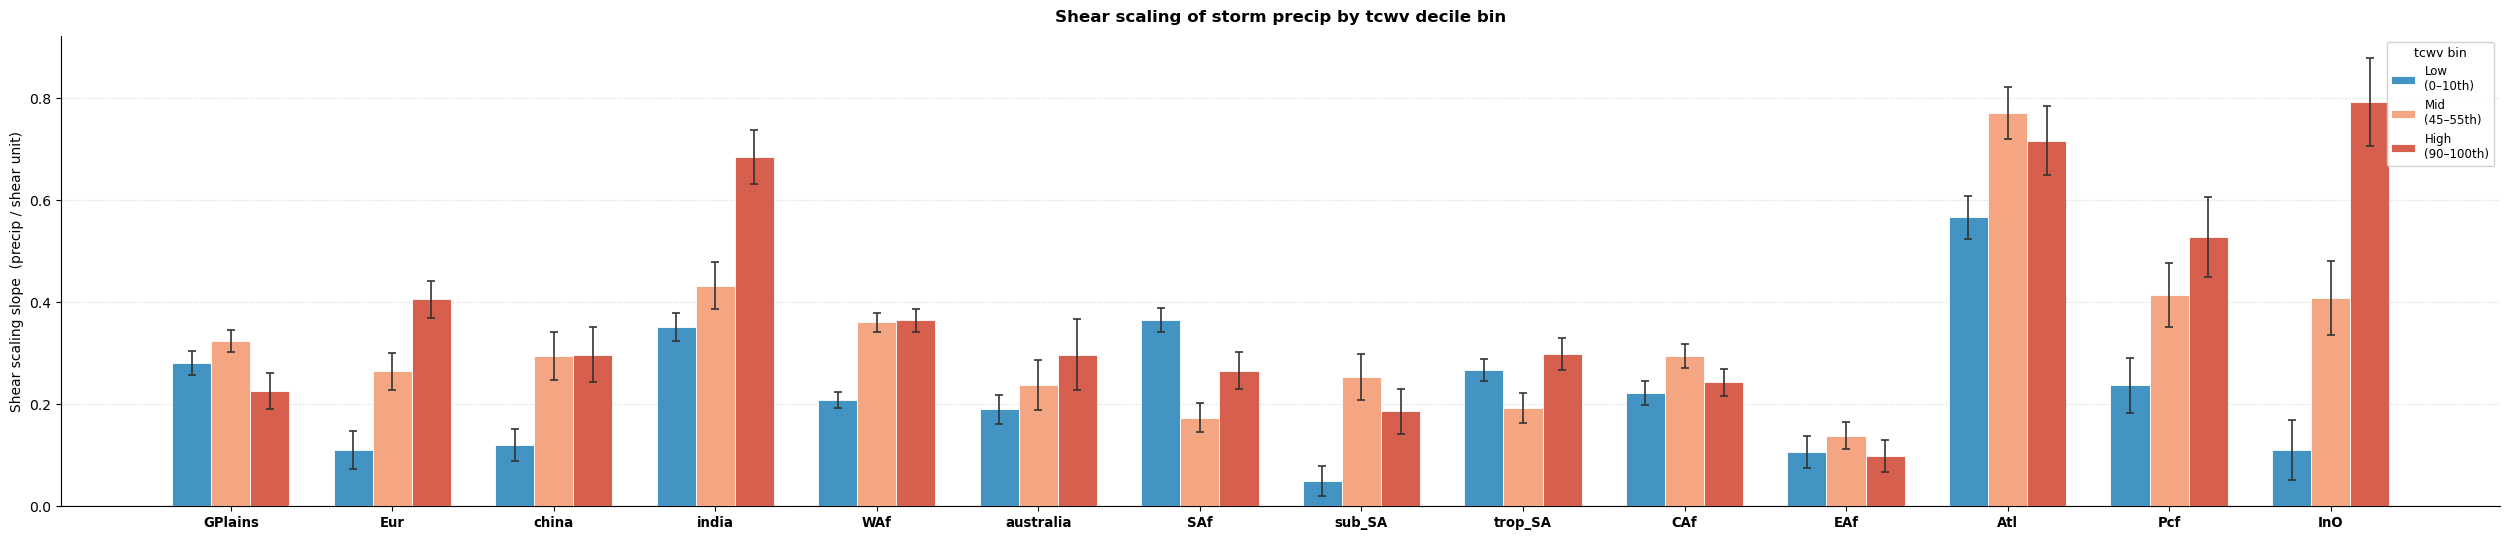

In [122]:
SHEAR_COL  = 'shear100_650'
TCW_COL    = 'tcwv'
PRECIP_COL = 'precipitation_max'
AREA_COL   = 'area'
plot_shear_scaling(
        df_env,
        response_col='precipitation_max',
        ylabel=f'Shear scaling slope  (precip / shear unit)',
        title=f'Shear scaling of storm precip by tcwv decile bin' )

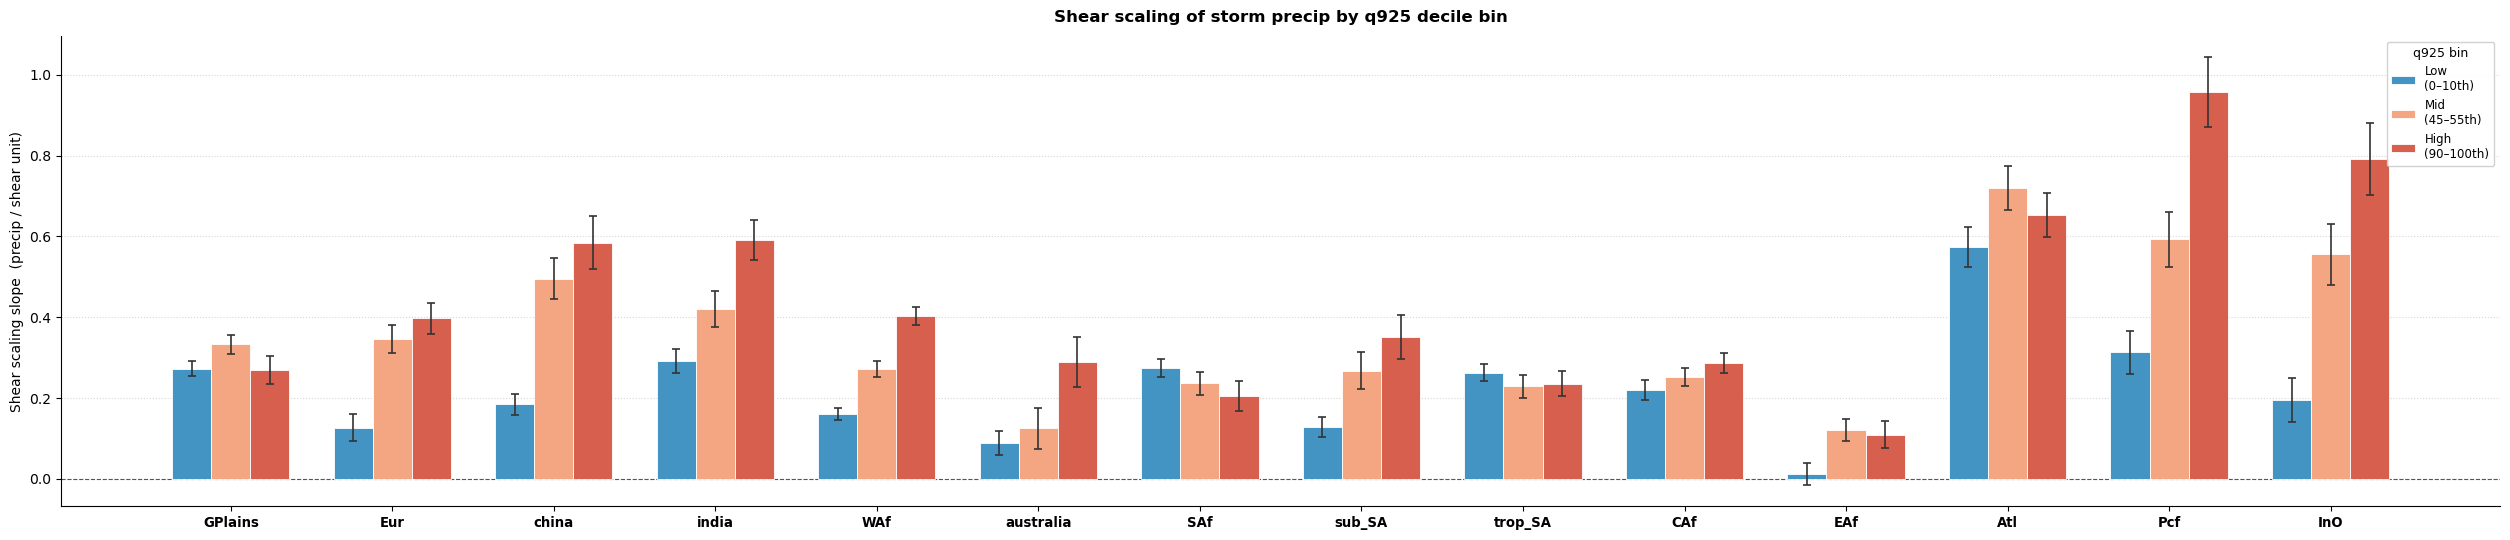

In [126]:
SHEAR_COL  = 'shear100_650'
TCW_COL    = 'q925'
PRECIP_COL = 'precipitation_max'
AREA_COL   = 'area'
plot_shear_scaling(
        df_env,
        response_col='precipitation_max',
        ylabel=f'Shear scaling slope  (precip / shear unit)',
        title=f'Shear scaling of storm precip by q925 decile bin' )

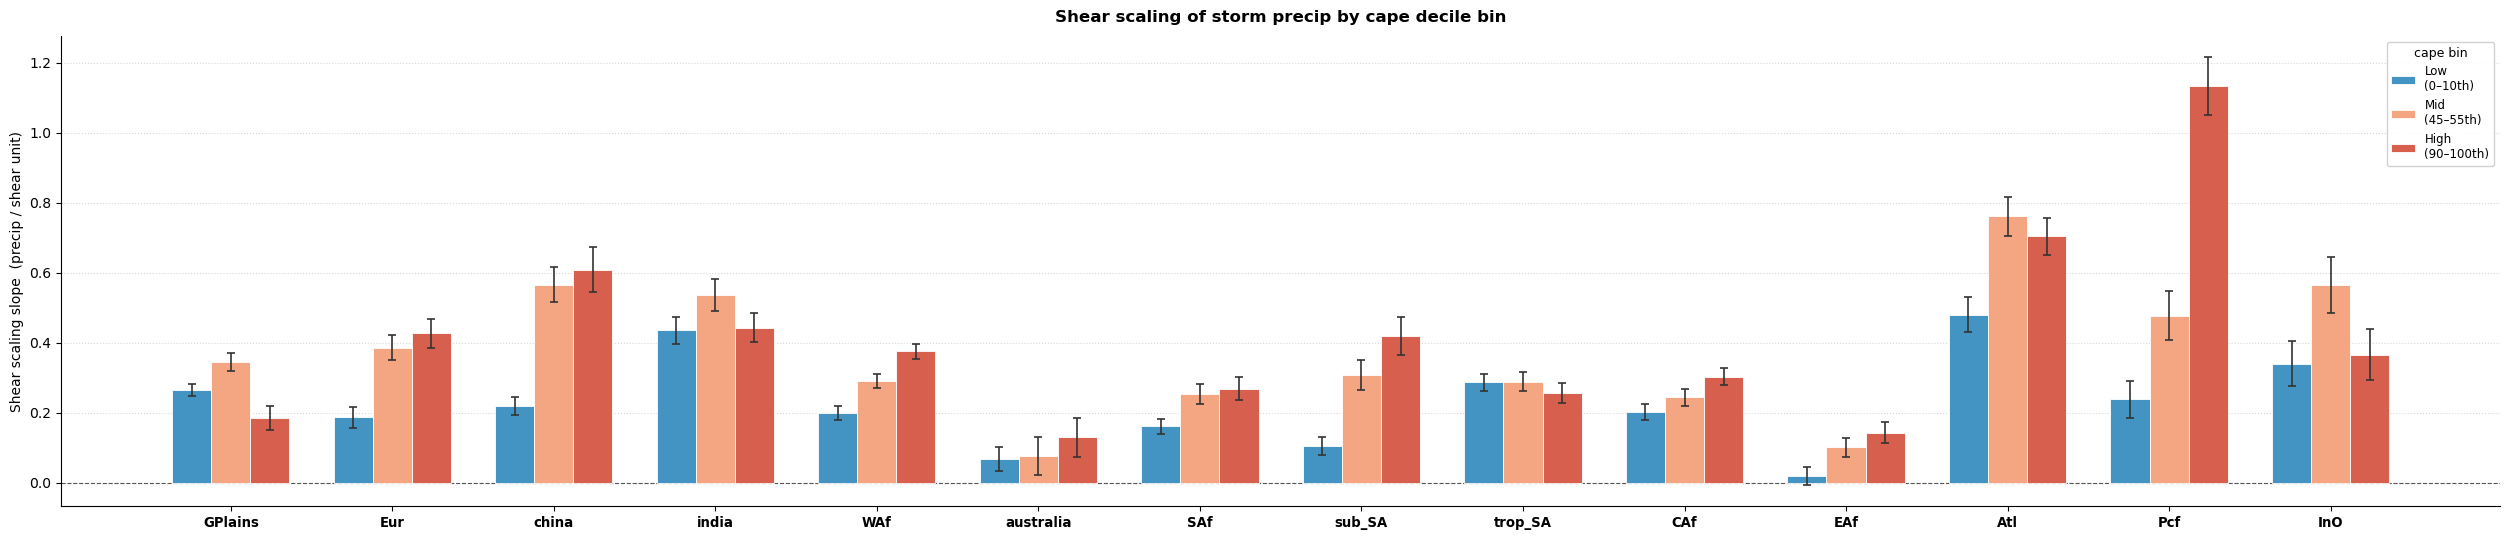

In [124]:
SHEAR_COL  = 'shear100_650'
TCW_COL    = 'cape'
PRECIP_COL = 'precipitation_max'
AREA_COL   = 'area'
plot_shear_scaling(
        df_env,
        response_col='precipitation_max',
        ylabel=f'Shear scaling slope  (precip / shear unit)',
        title=f'Shear scaling of storm precip by cape decile bin' )